## Init

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import emu_like.io as io
from emu_like.ffnn_emu import FFNNEmu

2025-10-07 10:11:33.408119: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 10:11:33.408529: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-07 10:11:33.410482: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-07 10:11:33.415512: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759824693.424921  159173 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759824693.42

In [ ]:
class EmuData(object):

    def __init__(self, emu):
        self.emu = emu
        self.mean_diff = None
        pass

    def scale_x(self, x):
        return self.emu.x_scaler.transform(x)

    def scale_y(self, y):
        return self.emu.y_scaler.transform(y)

    def inverse_scale_x(self, x):
        return self.emu.x_scaler.inverse_transform(x)

    def inverse_scale_y(self, y):
        return self.emu.y_scaler.inverse_transform(y)

    def pca_x(self, x):
        return self.emu.x_pca.transform(x)

    def pca_y(self, y):
        return self.emu.y_pca.transform(y)

    def inverse_pca_x(self, x):
        return self.emu.x_pca.inverse_transform(x)

    def inverse_pca_y(self, y):
        return self.emu.y_pca.inverse_transform(y)

    def get_y(self, x, scale_back=True, pca_back=True, modes_to_keep='all'):

        if pca_back is False and scale_back is True:
            raise Exception(' Inconsistent!')
        
        # Scale x
        if self.emu.x_scaler is None:
            x_scaled = x
        else:
            x_scaled = self.scale_x(x)
        # PCA x
        if self.emu.x_pca is None:
            x_scaled_pca = x_scaled
        else:
            x_scaled_pca = self.pca_x(x_scaled)

        # Emulate y
        y_scaled_pca = self.emu.model(x_scaled_pca, training=False)

        if modes_to_keep is not 'all':
            print('ppppppppppppppppppp')

        # inverse PCA y
        if pca_back is False or self.emu.y_pca is None:
            y_scaled = y_scaled_pca
        else:
            y_scaled = self.inverse_pca_y(y_scaled_pca)

        # Scale back y
        if scale_back is False or self.emu.y_scaler is None:
            y = y_scaled
        else:
            y = self.inverse_scale_y(y_scaled)

        return y

    def get_diff(self, y_data, x=None, y_emu=None, scale_back=True, pca_back=True):

        if y_emu is None and x is None:
            raise Exception('Inconsistent')
        elif y_emu is None:
            y_emu = self.get_y(x, scale_back=scale_back, pca_back=pca_back)

        # Scale y
        if scale_back is True or self.emu.y_scaler is None:
            y_scaled = y_data
        else:
            y_scaled = self.scale_y(y_data)

        # PCA y
        if pca_back is True or self.emu.y_pca is None:
            y_scaled_pca = y_scaled
        else:
            y_scaled_pca = self.pca_y(y_scaled)

        diff = y_emu/y_scaled_pca - 1.
        return diff
    
    def get_mean_diff(self, diff=None, y_data=None, x=None, y_emu=None, scale_back=True, pca_back=True):
        if diff is None:
            diff = self.get_diff(y_data, x=x, y_emu=y_emu, scale_back=scale_back, pca_back=pca_back)
        self.mean_diff = np.mean(diff**2., axis=1)
        return self.mean_diff
    
    def get_sorting_idxs(self):
        if self.mean_diff is None:
            raise Exception('Calculate mean_diff first')
        return self.mean_diff.argsort()[::-1]

In [3]:
path_emu = '/home/emilio/Data/emu_like/lcdm/train/{}_x{}'.format('cl_TT_lensed', 1)
emu = FFNNEmu()
emu.load(path_emu)

2025-10-07 10:11:34.978871: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/emilio/Codes/venv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/emilio/Codes/venv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
spectrum_type = 'cl'
spectrum = 'cl_TT_lensed'
nemus = range(1, 5)
dataset_types = ['thin', 'std', 'ext']

# Load emulators
emudata = {}
for nemu in nemus:
    path_emu = '/home/emilio/Data/emu_like/lcdm/train/{}_x{}'.format(spectrum, nemu)
    emu = FFNNEmu()
    emu.load(path_emu)
    emudata[nemu] = {}
    for dt in dataset_types:
        emudata[nemu][dt] = EmuData(emu)


x_data = {}
y_data = {}
for dt in dataset_types:
    path_dataset = '/home/emilio/Data/emu_like/lcdm/sample/{}_100_{}.fits'.format(spectrum_type, dt)
    dataset = io.FitsFile(path_dataset)
    x_data[dt] = dataset.get_data('x_data')
    y_data[dt] = dataset.get_data(spectrum)

## Histoghrams

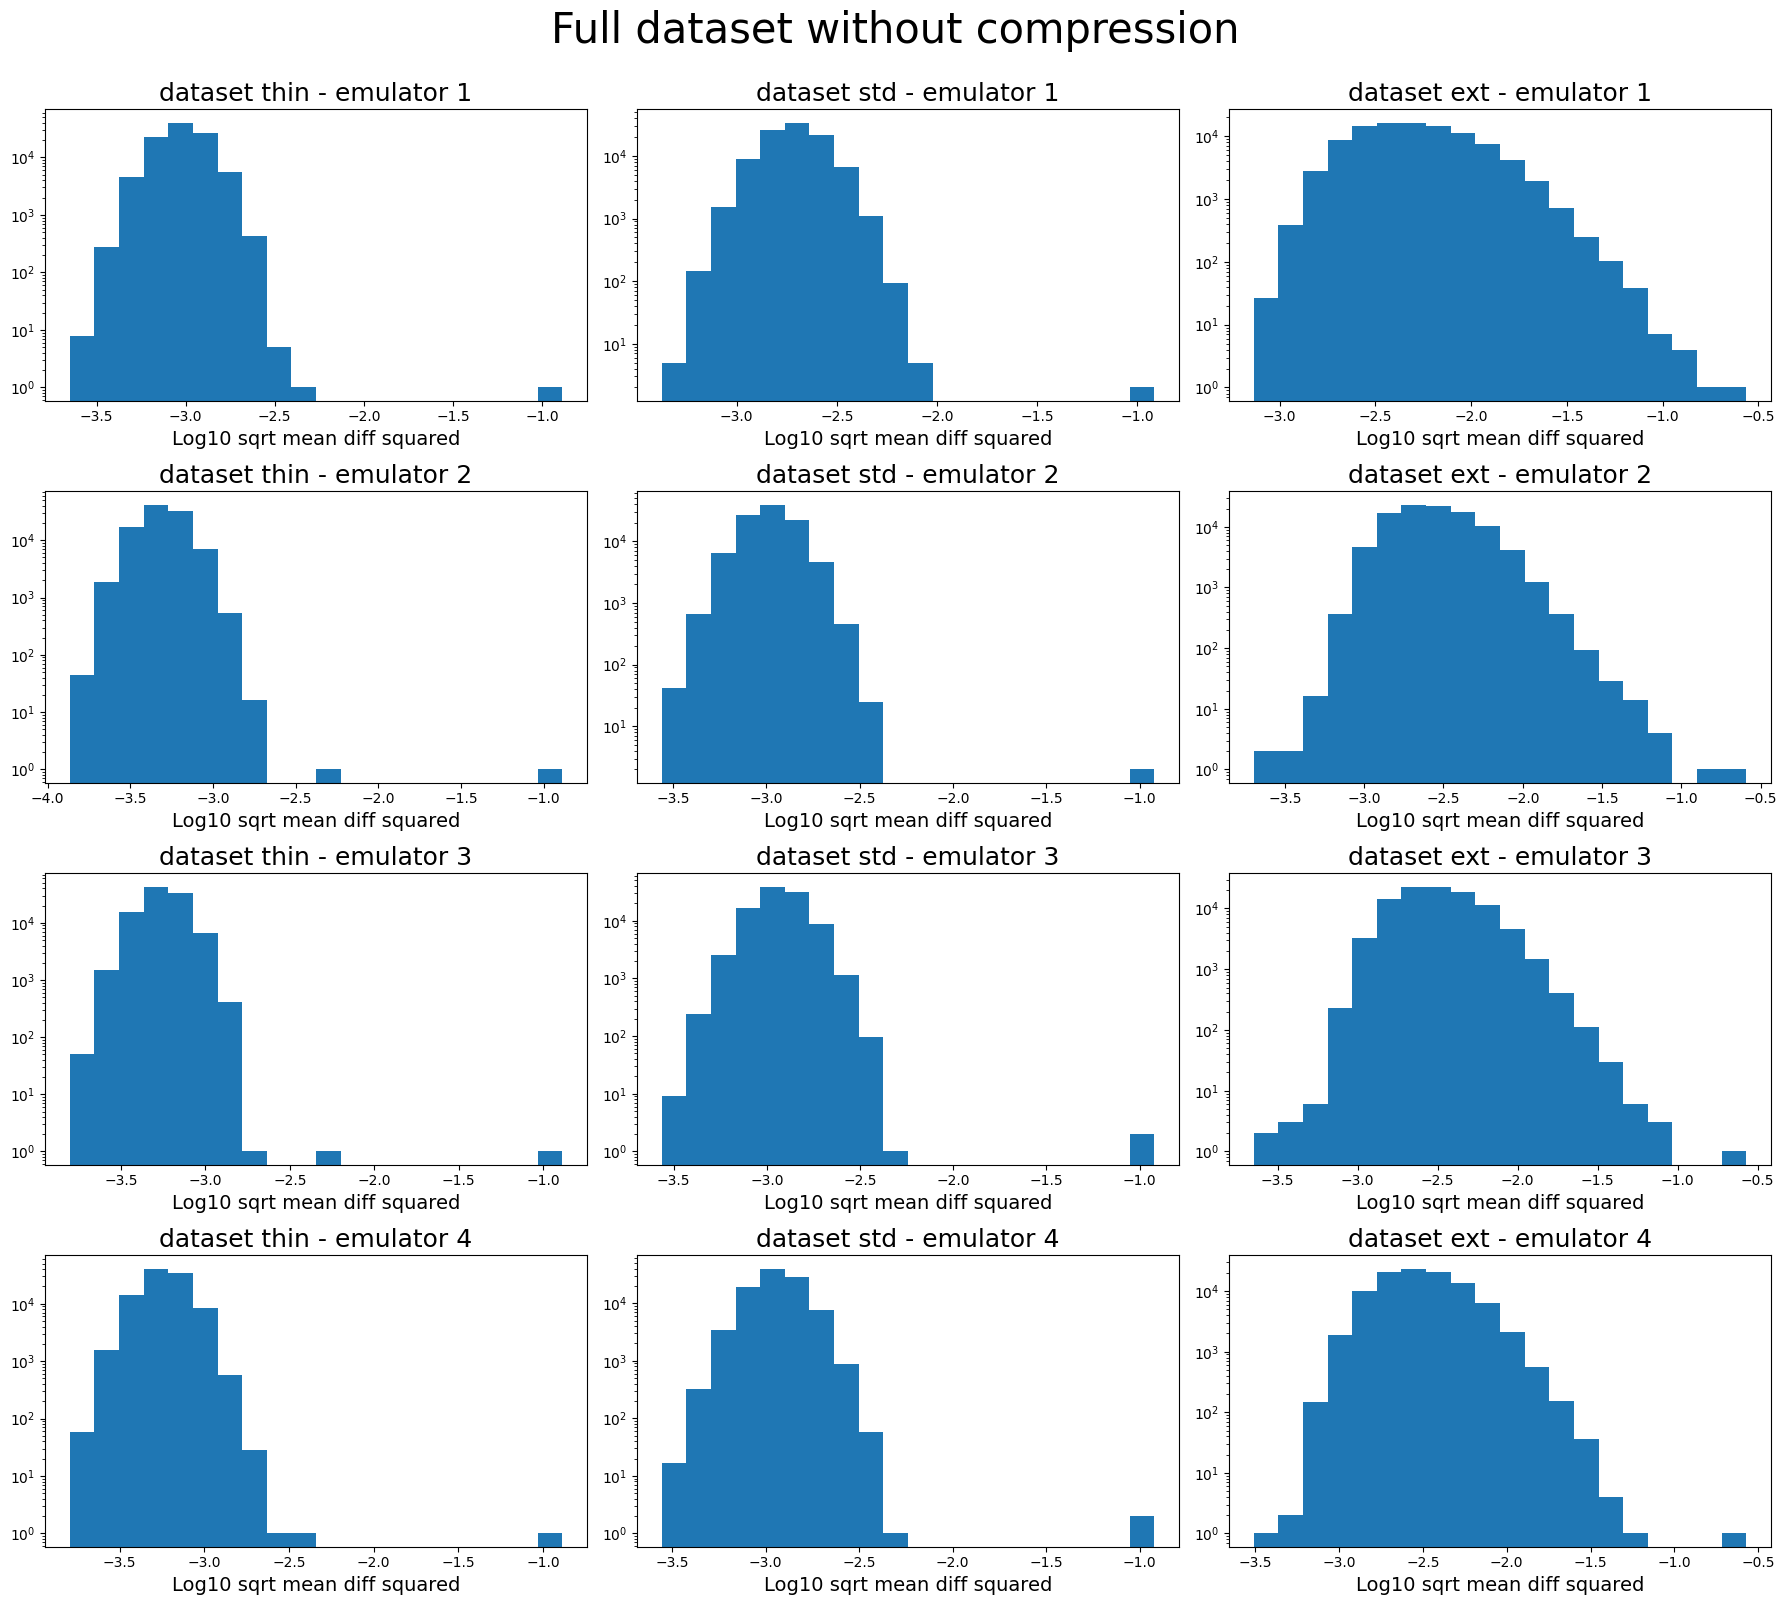

In [5]:
# Create figure
fig, axs = plt.subplots(len(nemus), len(dataset_types), figsize=(6*len(dataset_types), 4*len(nemus)), squeeze=False)
fig.suptitle('Full dataset without compression', fontsize=30, y=1.0)

# Plot data in each subplot
for nnemu, nemu in enumerate(nemus):
    for ndt, dt in enumerate(dataset_types):
        mean_diff = emudata[nemu][dt].get_mean_diff(
            y_data=y_data[dt],
            x=x_data[dt],
            scale_back=True,
            pca_back=True)

        axs[nnemu, ndt].hist(np.log10(np.sqrt(mean_diff)), log=True, bins=20)
        axs[nnemu, ndt].set_title('dataset {} - emulator {}'.format(dt, nemu), fontsize=18)
        axs[nnemu, ndt].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)


# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

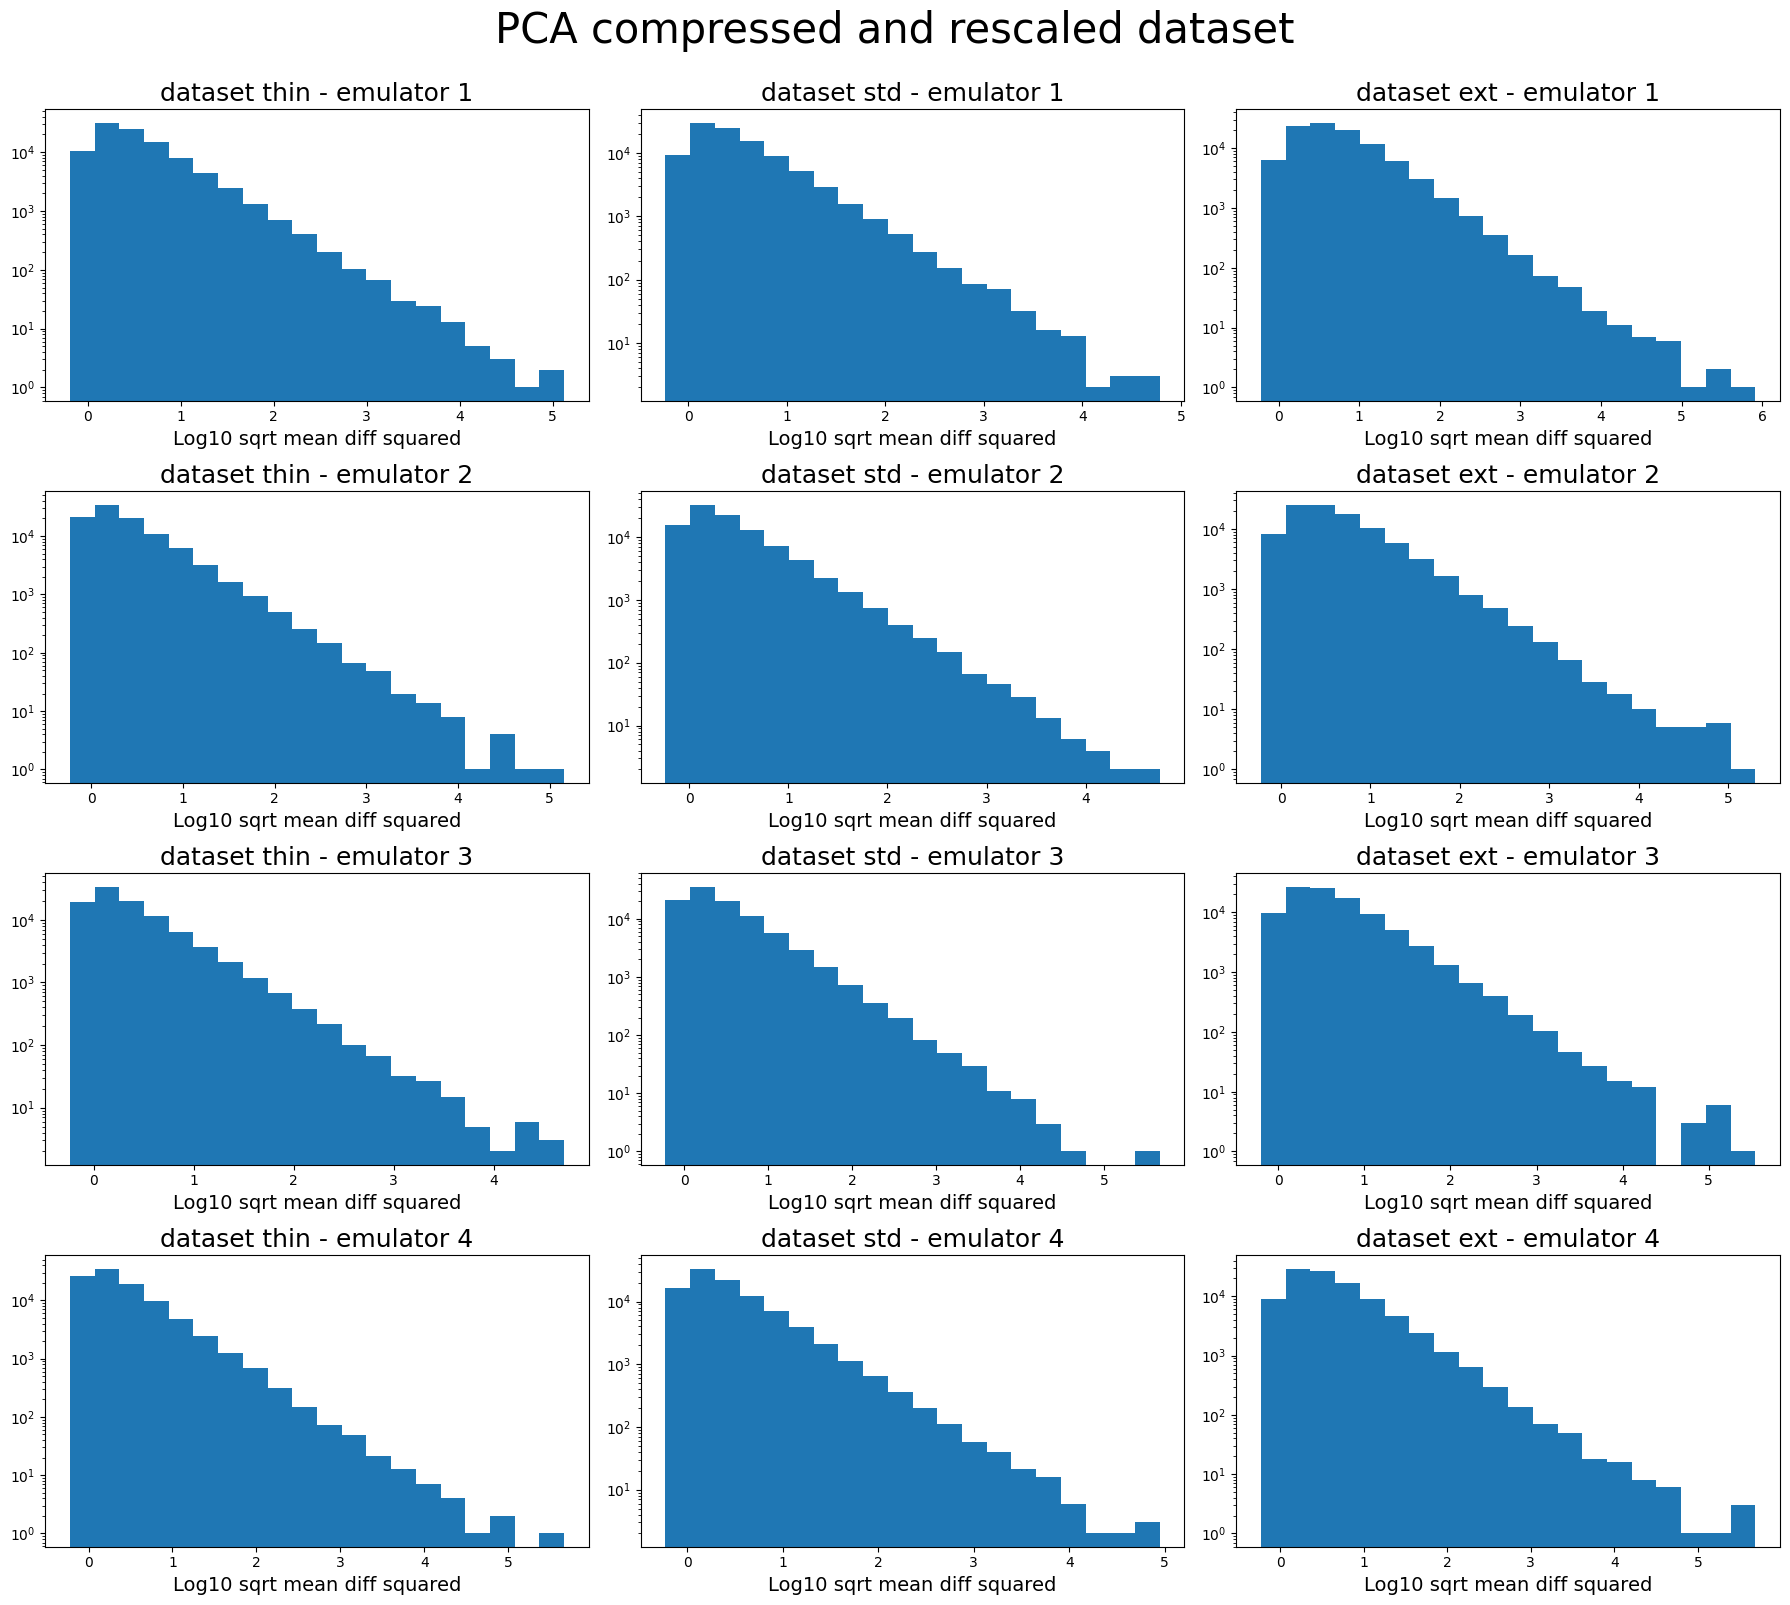

In [6]:
# Create figure
fig, axs = plt.subplots(len(nemus), len(dataset_types), figsize=(6*len(dataset_types), 4*len(nemus)), squeeze=False)
fig.suptitle('PCA compressed and rescaled dataset', fontsize=30, y=1.0)

# Plot data in each subplot
for nnemu, nemu in enumerate(nemus):
    for ndt, dt in enumerate(dataset_types):
        mean_diff = emudata[nemu][dt].get_mean_diff(
            y_data=y_data[dt],
            x=x_data[dt],
            scale_back=False,
            pca_back=False)

        axs[nnemu, ndt].hist(np.log10(np.sqrt(mean_diff)), log=True, bins=20)
        axs[nnemu, ndt].set_title('dataset {} - emulator {}'.format(dt, nemu), fontsize=18)
        axs[nnemu, ndt].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)


# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [56]:
def get_y(emudata, x, scale_back=True, pca_back=True, modes_to_keep='all'):

    if pca_back is False and scale_back is True:
        raise Exception(' Inconsistent!')
    
    # Scale x
    if emudata.emu.x_scaler is None:
        x_scaled = x
    else:
        x_scaled = emudata.scale_x(x)
    # PCA x
    if emudata.emu.x_pca is None:
        x_scaled_pca = x_scaled
    else:
        x_scaled_pca = emudata.pca_x(x_scaled)

    # Emulate y
    y_scaled_pca = emudata.emu.model(x_scaled_pca, training=False)

    # Select modes
    if modes_to_keep != 'all':
        y_scaled_pca_modes = np.zeros_like(y_scaled_pca)
        for nmode in range(len(y_scaled_pca[0])):
            if nmode in modes_to_keep:
                y_scaled_pca_modes[0, nmode] = y_scaled_pca[0, nmode]
    else:
        y_scaled_pca_modes = y_scaled_pca

    # inverse PCA y
    if pca_back is False or emudata.emu.y_pca is None:
        y_scaled = y_scaled_pca_modes
    else:
        y_scaled = emudata.inverse_pca_y(y_scaled_pca_modes)

    # Scale back y
    if scale_back is False or emudata.emu.y_scaler is None:
        y = y_scaled
    else:
        y = emudata.inverse_scale_y(y_scaled)

    return y

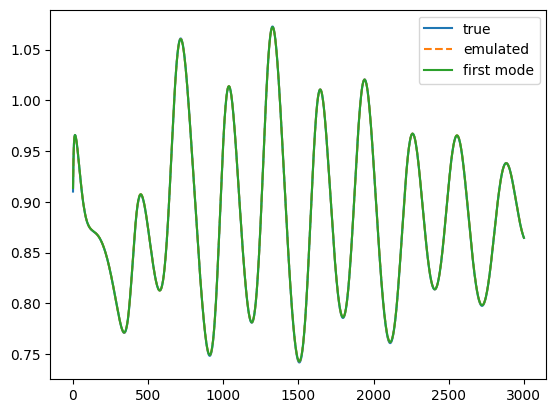

In [90]:
ell_range = np.arange(y_data['thin'].shape[1]) + 2
x_one = x_data['thin'][0]
y_one = y_data['thin'][0]
y_emu = get_y(emudata[2]['thin'], [x_one], scale_back=True, pca_back=True, modes_to_keep='all')[0]
y_mode = get_y(emudata[2]['thin'], [x_data['thin'][0]], scale_back=True, pca_back=True, modes_to_keep=range(40))[0]

plt.plot(ell_range, y_one, label='true')
plt.plot(ell_range, y_emu, '--', label='emulated')
plt.plot(ell_range, y_mode, label='first mode')



plt.legend()

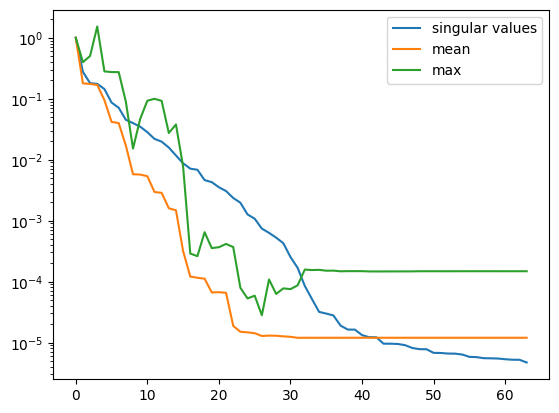

In [96]:
y_emu = get_y(emudata[2]['thin'], [x_one], scale_back=True, pca_back=True, modes_to_keep='all')[0]
y_one = y_data['thin'][0]
mean = []
max= []
for nmode in range(64):
    ratio = get_y(emudata[2]['thin'], [x_data['thin'][0]], scale_back=True, pca_back=True, modes_to_keep=range(nmode))[0]/y_one
    mean.append(np.mean((ratio-1.)**2.))
    max.append(np.max((ratio-1.)**2.))

plt.plot(emudata[2]['thin'].emu.y_pca.pca.singular_values_/emudata[2]['thin'].emu.y_pca.pca.singular_values_[0], label='singular values')
plt.plot(mean/mean[0], label='mean')
plt.plot(max/max[0], label='max')
plt.yscale('log')
plt.legend()

In [92]:
y_mode = get_y(emudata[2]['thin'], [x_data['thin'][0]], scale_back=True, pca_back=True, modes_to_keep=range(40))[0]/y_emu
print(y_mode)

[1.00000688 0.99998907 0.99999147 ... 1.00001048 1.0000113  1.00001219]


In [ ]:

mean_y = np.mean(y_data['thin'], axis=0)
print(ell_range.shape)
print(mean_y.shape)

(2999,)
(2999,)


In [25]:
x_data['thin'][0].shape

(6,)

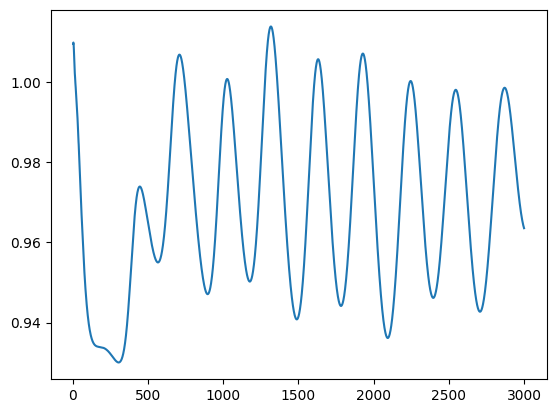

In [78]:
plt.plot(ell_range, mean_y)

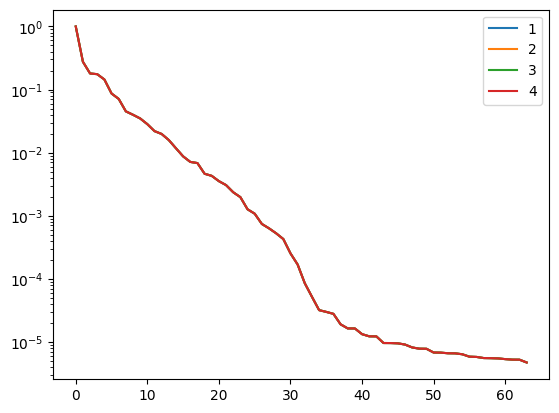

In [86]:
for nemu in nemus:
    plt.plot(emudata[nemu]['thin'].emu.y_pca.pca.singular_values_/emudata[nemu]['thin'].emu.y_pca.pca.singular_values_[0], label=nemu)
plt.yscale('log')
plt.legend()

In [11]:
dir(emudata[1]['thin'].emu.y_pca.pca)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_fit',
 '_fit_full',
 '_fit_svd_solver',
 '_fit_truncated',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_n_features_out',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sklearn_auto_wrap_output_keys',
 '_transform',

## Worst fits

In [ ]:
# Create figure
fig, axs = plt.subplots(len(nemus), len(dataset_types), figsize=(6*len(dataset_types), 4*len(nemus)), squeeze=False)
fig.suptitle('PCA compressed and rescaled dataset', fontsize=30, y=1.0)

# Plot data in each subplot
for nnemu, nemu in enumerate(nemus):
    for ndt, dt in enumerate(dataset_types):
        mean_diff = emudata[nemu][dt].get_mean_diff(
            y_data=y_data[dt],
            x=x_data[dt],
            scale_back=False,
            pca_back=False)

        axs[nnemu, ndt].hist(np.log10(np.sqrt(mean_diff)), log=True, bins=20)
        axs[nnemu, ndt].set_title('dataset {} - emulator {}'.format(dt, nemu), fontsize=18)
        axs[nnemu, ndt].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)


# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
emudata[nemu][dt].get_mean_diff(
    y_data=y_data[dt],
    x=x_data[dt],
    scale_back=True,
    pca_back=True)

In [ ]:


diff = emudata.get_diff(y_data, x=x_data, y_emu=None, scale_back=False, pca_back=False)

emudata.get_mean_diff(diff=None, y_data=y_data, x=x_data, y_emu=None, scale_back=True, pca_back=True)

emudata.get_mean_diff(diff=diff, y_data=y_data, x=x_data, y_emu=None, scale_back=True, pca_back=True)
emudata.get_sorting_idxs()

In [ ]:
nemu = 4
cosmo_param = 0
n_data = 4

# Sample data - list of curves and their parameters
curves = diff[nemu].diff[1:n_data]*100
parameters_all = diff[nemu].x[1:n_data, cosmo_param]
parameters = parameters_all  # Your curve-dependent parameters
# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize parameters to [0,1] range for colormap
norm = mpl.colors.Normalize(vmin=min(parameters_all), vmax=max(parameters_all))
cmap = plt.cm.twilight_shifted

# Plot each curve with color based on parameter
for curve, param in zip(curves, parameters):
    color = cmap(norm(param))
    ax.plot(curve.T, color=color)
ax.set_xscale('log')

# Add colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Parameter Value')

plt.show()

In [ ]:
nemu = 4
cosmo_param = 0
n_data = 10

# Sample data - list of curves and their parameters
curves = diff[nemu].diff[-n_data:]*100
parameters_all = diff[nemu].x[-n_data:, cosmo_param]
parameters = parameters_all  # Your curve-dependent parameters
# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize parameters to [0,1] range for colormap
norm = mpl.colors.Normalize(vmin=min(parameters_all), vmax=max(parameters_all))
cmap = plt.cm.twilight_shifted

# Plot each curve with color based on parameter
for curve, param in zip(curves, parameters):
    color = cmap(norm(param))
    ax.plot(curve.T, color=color)
ax.set_xscale('log')

# Add colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Parameter Value')

plt.show()

In [ ]:
diff[4].x[0]

In [ ]:
emu[4].x_names

In [ ]:
plt.hist(np.log10(np.sqrt(diff[4].mean_diff)), log=True, bins=100)

In [ ]:
np.min(diff[4].x, axis=0)

In [ ]:
np.max(diff[4].x, axis=0)

In [ ]:
diff[4].x[0]